## “Customer Segmentation Blueprint: Unsupervised Discovery of Actionable Personas with PCA & K-Means”

**Objective**  
Transform unlabeled retail customer data into mathematically isolated and strategically actionable market segments using a complete enterprise pipeline:

1. **SCALE** → Standardization  
2. **COMPRESS** → Principal Component Analysis (PCA)  
3. **CLUSTER** → K-Means + Elbow Method + Silhouette Score  
4. **TRANSLATE** → Business Personas & Marketing Actions

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Set nice plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

In [4]:
# Cell 2: Load the dataset
# Dataset got from kaggle
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Quick exploration
print(df.info())
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Descriptive statistics ---")
print(df.describe())
print("\n--- Gender distribution ---")
print(df['Genre'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

--- Missing values ---
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Descriptive statistics ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264

## 1. Data Understanding & Preprocessing

### 1.1 Dataset Overview
The Mall Customers dataset contains 200 records with the following features:
- `CustomerID`: Unique identifier
- `Genre`: Gender of the customer (Male / Female)
- `Age`: Age in years
- `Annual Income (k$)`: Annual income in thousands of dollars
- `Spending Score (1-100)`: Score assigned by the mall based on customer behavior and spending nature

### 1.2 Why Preprocessing is Critical
K-Means uses **Euclidean distance**. Features with larger scales (e.g., Annual Income) would completely dominate smaller-scale features (e.g., Age or Spending Score). Therefore we must:
1. Encode categorical variables
2. Select relevant features
3. Standardize all numerical features (mean = 0, std = 1)

In [11]:
# STEP 2: Data Preprocessing & Standardization
# 1. Rename columns for cleaner code 
df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

print("Columns after renaming:")
print(df.columns.tolist())
print()


Columns after renaming:
['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']



In [13]:
# 2. Encode Gender (Male=0, Female=1)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

print("Gender Encoding:")
print(df[['Gender', 'Gender_Encoded']].head(8))
print()


Gender Encoding:
   Gender  Gender_Encoded
0    Male               1
1    Male               1
2  Female               0
3  Female               0
4  Female               0
5  Female               0
6  Female               0
7  Female               0



In [17]:
# 3. Select features for clustering
# We keep Age, Annual_Income, Spending_Score (classic 3 features)
# + Gender_Encoded
features = ['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']
X = df[features].copy()

print("Features selected for modeling:")
print(X.head())
print("\nShape:", X.shape)

Features selected for modeling:
   Age  Annual_Income  Spending_Score  Gender_Encoded
0   19             15              39               1
1   21             15              81               1
2   20             16               6               0
3   23             16              77               0
4   31             17              40               0

Shape: (200, 4)


In [19]:
# 4. Standardization (Critical Step)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\n--- After Standardization (first 5 rows) ---")
print(X_scaled_df.head())
print("\nMean of scaled features (should be ~0):")
print(X_scaled_df.mean().round(6))
print("\nStd of scaled features (should be ~1):")
print(X_scaled_df.std().round(6))


--- After Standardization (first 5 rows) ---
        Age  Annual_Income  Spending_Score  Gender_Encoded
0 -1.424569      -1.738999       -0.434801        1.128152
1 -1.281035      -1.738999        1.195704        1.128152
2 -1.352802      -1.700830       -1.715913       -0.886405
3 -1.137502      -1.700830        1.040418       -0.886405
4 -0.563369      -1.662660       -0.395980       -0.886405

Mean of scaled features (should be ~0):
Age              -0.0
Annual_Income    -0.0
Spending_Score   -0.0
Gender_Encoded    0.0
dtype: float64

Std of scaled features (should be ~1):
Age               1.002509
Annual_Income     1.002509
Spending_Score    1.002509
Gender_Encoded    1.002509
dtype: float64


## 2. Dimensionality Reduction with Principal Component Analysis (PCA)

### Why PCA?
Enterprise datasets often contain 20+ features. In high-dimensional space, Euclidean distance loses meaning (Curse of Dimensionality). PCA solves this by:

- Finding orthogonal axes (Principal Components) that capture maximum variance
- Projecting the data onto a lower-dimensional space while preserving the most important behavioral signals
- Enabling better clustering and visualization

### The 95% Rule
We retain the minimum number of components that explain **at least 95%** of the total variance.

In [22]:
# STEP 3: Principal Component Analysis (PCA)

# Fit PCA on the scaled data (keep all components first to analyze variance)
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance ratio
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio per Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print("\nCumulative Explained Variance:")
for i, cum in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum:.4f} ({cum*100:.2f}%)")

# Find number of components for ≥ 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components needed for ≥95% variance: {n_components_95}")

Explained Variance Ratio per Component:
PC1: 0.3369 (33.69%)
PC2: 0.2623 (26.23%)
PC3: 0.2326 (23.26%)
PC4: 0.1682 (16.82%)

Cumulative Explained Variance:
PC1 to PC1: 0.3369 (33.69%)
PC1 to PC2: 0.5992 (59.92%)
PC1 to PC3: 0.8318 (83.18%)
PC1 to PC4: 1.0000 (100.00%)

Number of components needed for ≥95% variance: 4


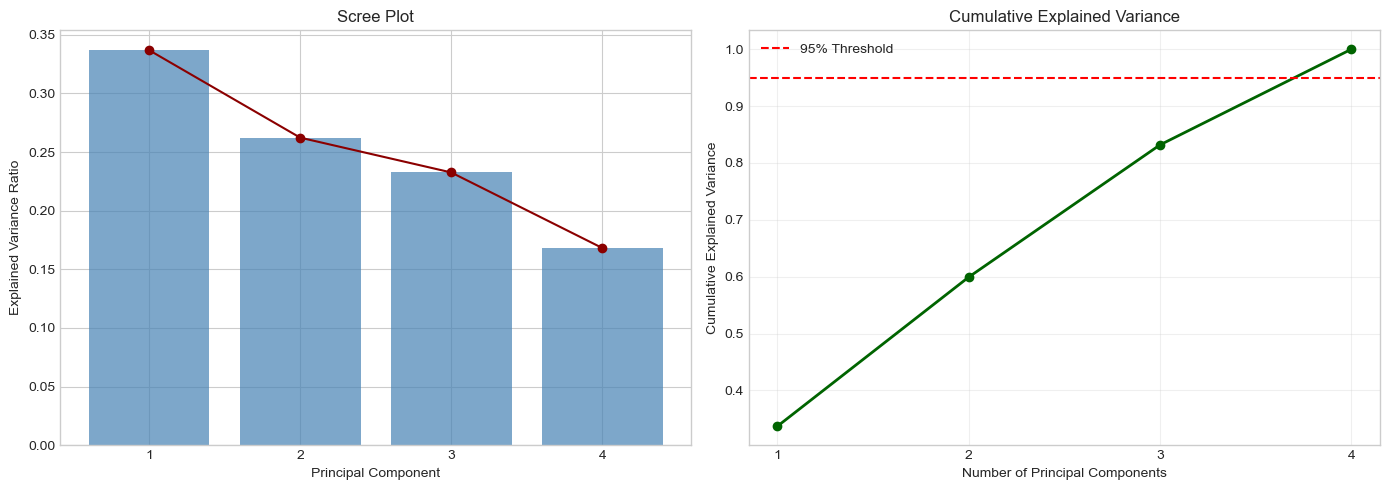


PCA applied → Reduced from 4 features to 4 components
Total variance retained: 100.00%


In [26]:
# Visualize Explained Variance (Scree Plot + Cumulative)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue')
ax[0].plot(range(1, len(explained_variance)+1), explained_variance, 'o-', color='darkred')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')
ax[0].set_title('Scree Plot')
ax[0].set_xticks(range(1, len(explained_variance)+1))

# Cumulative variance
ax[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-', color='darkgreen', linewidth=2)
ax[1].axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
ax[1].set_xlabel('Number of Principal Components')
ax[1].set_ylabel('Cumulative Explained Variance')
ax[1].set_title('Cumulative Explained Variance')
ax[1].legend()
ax[1].set_xticks(range(1, len(cumulative_variance)+1))
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply PCA with chosen number of components
# For visualization we often use 2 or 3; for clustering we can use the 95% rule

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA applied → Reduced from {X_scaled.shape[1]} features to {X_pca.shape[1]} components")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

In [28]:
# Create DataFrame for the PCA results
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
print("\nFirst 5 rows of PCA-transformed data:")
print(X_pca_df.head())


First 5 rows of PCA-transformed data:
        PC1       PC2       PC3       PC4
0 -0.406383 -0.520714 -2.072527  1.335529
1 -1.427673 -0.367310 -2.277644  0.082329
2  0.050761 -1.894068 -0.367375  2.174381
3 -1.694513 -1.631908 -0.717467  0.075228
4 -0.313108 -1.810483 -0.426460  0.683070


## 3. Determining the Optimal Number of Clusters (K)

K-Means requires us to specify the number of clusters (`K`) in advance.  
To choose the mathematically optimal `K`, we use two diagnostic gatekeepers:

### 1. Elbow Method
- Plots **Within-Cluster Sum of Squares (WCSS)** against different values of K
- The “elbow” point indicates the optimal K (diminishing returns after this point)

### 2. Silhouette Score
- Measures how similar a point is to its own cluster vs. other clusters
- Score ranges from -1 to +1
- Higher average Silhouette Score = better defined clusters

In [31]:
# STEP 4: Finding Optimal K – Elbow Method + Silhouette Score
# We will test K from 2 to 10
k_range = range(2, 11)

wcss = []                  # Within-Cluster Sum of Squares
silhouette_scores = []     # Silhouette scores

print("Calculating WCSS and Silhouette Score for K = 2 to 10...\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_pca)      # Using PCA-transformed data
    
    wcss.append(kmeans.inertia_)
    
    # Silhouette score needs at least 2 clusters
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"K = {k:2d} | WCSS = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

Calculating WCSS and Silhouette Score for K = 2 to 10...

K =  2 | WCSS = 588.80 | Silhouette Score = 0.2518
K =  3 | WCSS = 476.79 | Silhouette Score = 0.2595
K =  4 | WCSS = 388.72 | Silhouette Score = 0.2984
K =  5 | WCSS = 331.31 | Silhouette Score = 0.3041
K =  6 | WCSS = 276.41 | Silhouette Score = 0.3311
K =  7 | WCSS = 236.20 | Silhouette Score = 0.3574
K =  8 | WCSS = 199.75 | Silhouette Score = 0.3880
K =  9 | WCSS = 174.24 | Silhouette Score = 0.4031
K = 10 | WCSS = 152.03 | Silhouette Score = 0.4208


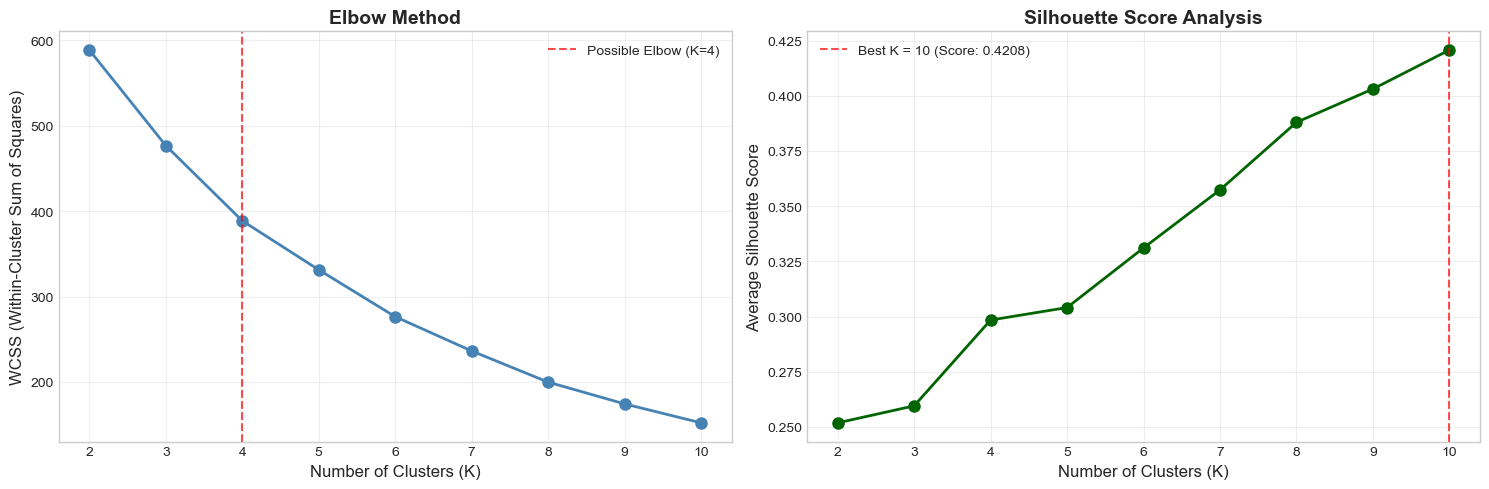


Highest Silhouette Score is at K = 10


In [33]:
# Visualization: Elbow Method + Silhouette Score
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
ax[0].plot(k_range, wcss, 'o-', color='steelblue', linewidth=2, markersize=8)
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
ax[0].set_xticks(list(k_range))
ax[0].grid(True, alpha=0.3)

# Highlight possible elbow (you can adjust after seeing the plot)
# Common choices for this dataset are K=4 or K=5
ax[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Possible Elbow (K=4)')
ax[0].legend()

# Silhouette Score
ax[1].plot(k_range, silhouette_scores, 'o-', color='darkgreen', linewidth=2, markersize=8)
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12)
ax[1].set_ylabel('Average Silhouette Score', fontsize=12)
ax[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
ax[1].set_xticks(list(k_range))
ax[1].grid(True, alpha=0.3)

# Highlight the best silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
ax[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, 
              label=f'Best K = {best_k} (Score: {max(silhouette_scores):.4f})')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"\nHighest Silhouette Score is at K = {best_k}")

## 4. Final K-Means Clustering (K = 4)

We now train the final K-Means model with the optimal number of clusters (K=4) on the PCA-transformed data.

After clustering, we will:
1. Assign cluster labels to every customer
2. Visualize the clusters in 2D PCA space
3. Reverse-engineer the cluster centroids back to the original feature scale (Age, Income, Spending Score)

In [36]:
# STEP 5: Final K-Means Clustering (K = 4)

# Train final model
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Add cluster labels to the original dataframe
df['Cluster'] = cluster_labels

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print()

Cluster distribution:
Cluster
0    56
1    46
2    56
3    42
Name: count, dtype: int64



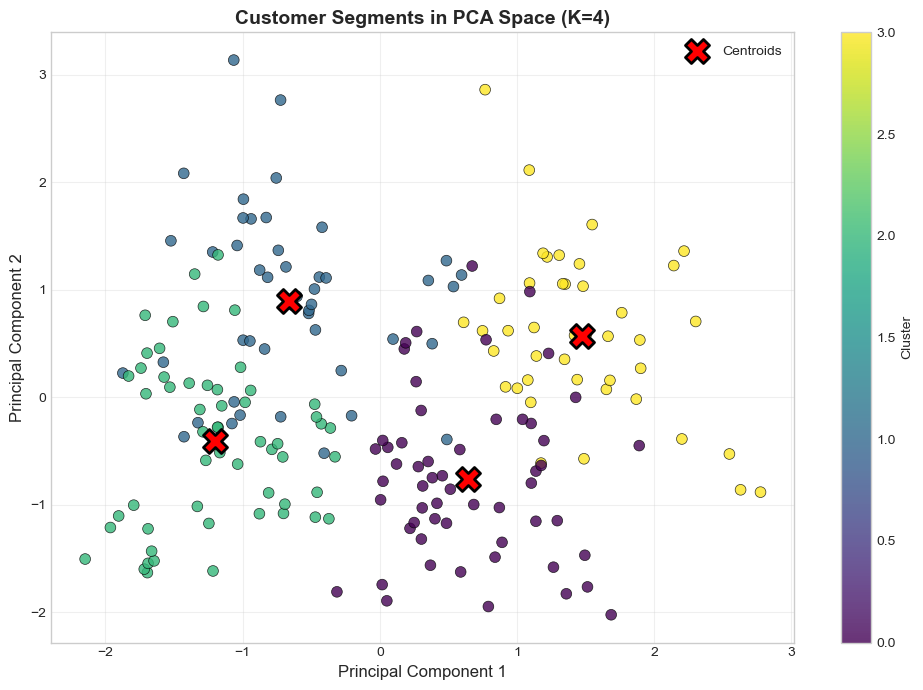

Final model trained successfully!
Inertia (WCSS): 388.72
Silhouette Score: 0.2984


In [38]:
# 2D PCA Visualization of Clusters
plt.figure(figsize=(10, 7))

# Scatter plot of the first two principal components
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=cluster_labels, 
                      cmap='viridis', 
                      s=60, 
                      alpha=0.8,
                      edgecolors='k',
                      linewidth=0.5)

# Plot the cluster centroids in PCA space
centroids_pca = kmeans_final.cluster_centers_
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            s=300, c='red', marker='X', 
            edgecolors='black', linewidth=2,
            label='Centroids')

plt.title(f'Customer Segments in PCA Space (K={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final model trained successfully!")
print(f"Inertia (WCSS): {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_pca, cluster_labels):.4f}")

## 5. From Clusters to Business Personas

K-Means was run in the reduced PCA space. The centroids exist in abstract coordinates that mean nothing to a marketing team.

### Reverse Engineering Process
1. Take the cluster centroids from PCA space
2. Inverse-transform them back through PCA
3. Inverse-transform them through the StandardScaler
4. Obtain human-readable values: Age, Annual Income, Spending Score, Gender ratio

We then assign strategic names and recommended marketing actions to each persona.

In [41]:
# STEP 6: Reverse Engineering Centroids + Persona Creation

# 1. Get centroids in PCA space
centroids_pca = kmeans_final.cluster_centers_

# 2. Inverse transform: PCA → Scaled space
centroids_scaled = pca.inverse_transform(centroids_pca)

# 3. Inverse transform: Scaled → Original feature space
centroids_original = scaler.inverse_transform(centroids_scaled)

# Create a clean DataFrame of centroids
centroid_df = pd.DataFrame(centroids_original, 
                           columns=['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded'])
centroid_df['Cluster'] = range(optimal_k)
centroid_df = centroid_df[['Cluster', 'Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']]

# Convert Gender_Encoded back to approximate % Female
# (0 = Male, 1 = Female → higher value means more females)
centroid_df['Female_Percentage'] = (centroid_df['Gender_Encoded'] * 100).round(1)

print("="*70)
print("CLUSTER CENTROIDS (Original Scale)")
print("="*70)
print(centroid_df.round(1).to_string(index=False))
print()

CLUSTER CENTROIDS (Original Scale)
 Cluster  Age  Annual_Income  Spending_Score  Gender_Encoded  Female_Percentage
       0 47.8           58.1            34.9            -0.0               -0.0
       1 28.0           62.2            64.8             1.0              100.0
       2 28.4           60.4            68.2             0.0                0.0
       3 52.7           62.2            30.6             1.0              100.0



In [43]:
# Detailed Cluster Profiles from the actual data
print("DETAILED CLUSTER PROFILES (from actual customers)")

profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Gender': lambda x: (x == 'Female').mean() * 100,  # % Female
    'CustomerID': 'count'
}).round(1)

profile.columns = ['Avg_Age', 'Avg_Income (k$)', 'Avg_Spending_Score', '%_Female', 'Count']
print(profile)
print()

# ---------------------------------------------------------
# Assign Business Personas (matching DecodeLabs style)
# ---------------------------------------------------------
# We map clusters based on Income + Spending Score patterns

def assign_persona(row):
    income = row['Avg_Income (k$)']
    score = row['Avg_Spending_Score']
    age = row['Avg_Age']
    
    if income > 70 and score < 40:
        return "The Affluent Conservatives"
    elif income > 70 and score > 70:
        return "The High-Value Trendsetters"
    elif income < 40 and score > 70:
        return "The Budget-Conscious Explorers"
    else:
        return "The Conservative Minimizers"

profile['Persona'] = profile.apply(assign_persona, axis=1)

# Recommended Actions
actions = {
    "The Affluent Conservatives": "High-touch support, warranties, loyalty programs, premium services",
    "The High-Value Trendsetters": "Exclusive perks, early access, experiential marketing, VIP events",
    "The Budget-Conscious Explorers": "Influencer campaigns, flash sales, buy-now-pay-later, trendy affordable products",
    "The Conservative Minimizers": "Clear price value, basic utility products, minimize marketing spend, retention offers"
}

profile['Recommended_Action'] = profile['Persona'].map(actions)

print("STRATEGIC PERSONA MATRIX")
print(profile[['Persona', 'Avg_Age', 'Avg_Income (k$)', 'Avg_Spending_Score', '%_Female', 'Count', 'Recommended_Action']].to_string())

DETAILED CLUSTER PROFILES (from actual customers)
         Avg_Age  Avg_Income (k$)  Avg_Spending_Score  %_Female  Count
Cluster                                                               
0           47.8             58.1                34.9     100.0     56
1           28.0             62.2                64.8       0.0     46
2           28.4             60.4                68.2     100.0     56
3           52.7             62.2                30.6       0.0     42

STRATEGIC PERSONA MATRIX
                             Persona  Avg_Age  Avg_Income (k$)  Avg_Spending_Score  %_Female  Count                                                                     Recommended_Action
Cluster                                                                                                                                                                                   
0        The Conservative Minimizers     47.8             58.1                34.9     100.0     56  Clear price value, basi

## 6.Visualizations & Business Insights

We now create professional visualizations that clearly communicate the four customer personas to stakeholders.

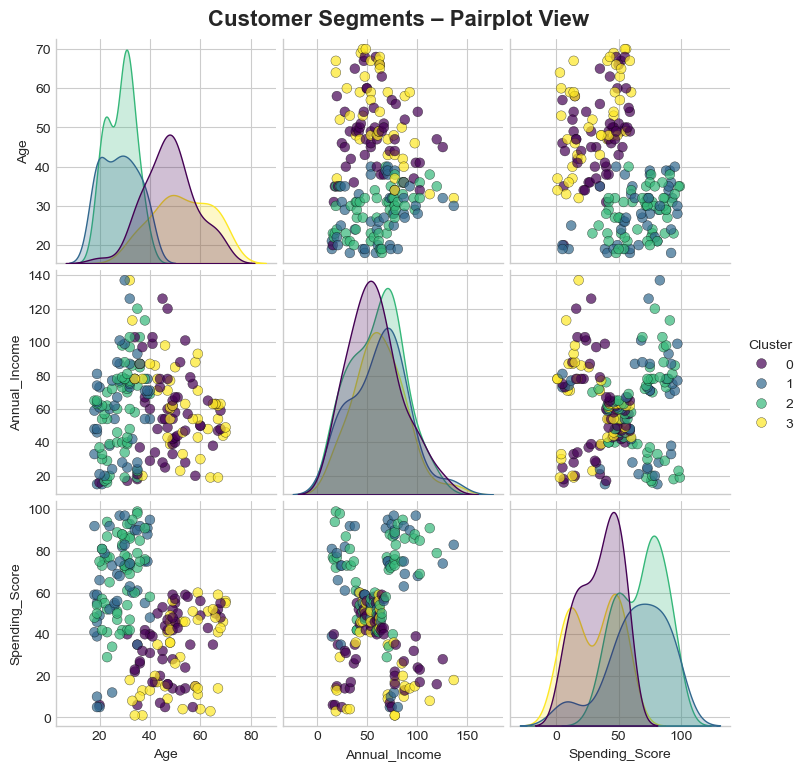

In [48]:
# STEP 7: Final Professional Visualizations
sns.pairplot(df, 
             vars=['Age', 'Annual_Income', 'Spending_Score'], 
             hue='Cluster', 
             palette='viridis',
             diag_kind='kde',
             plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k', 'linewidth': 0.3})
plt.suptitle('Customer Segments – Pairplot View', y=1.02, fontsize=16, fontweight='bold')
plt.show()



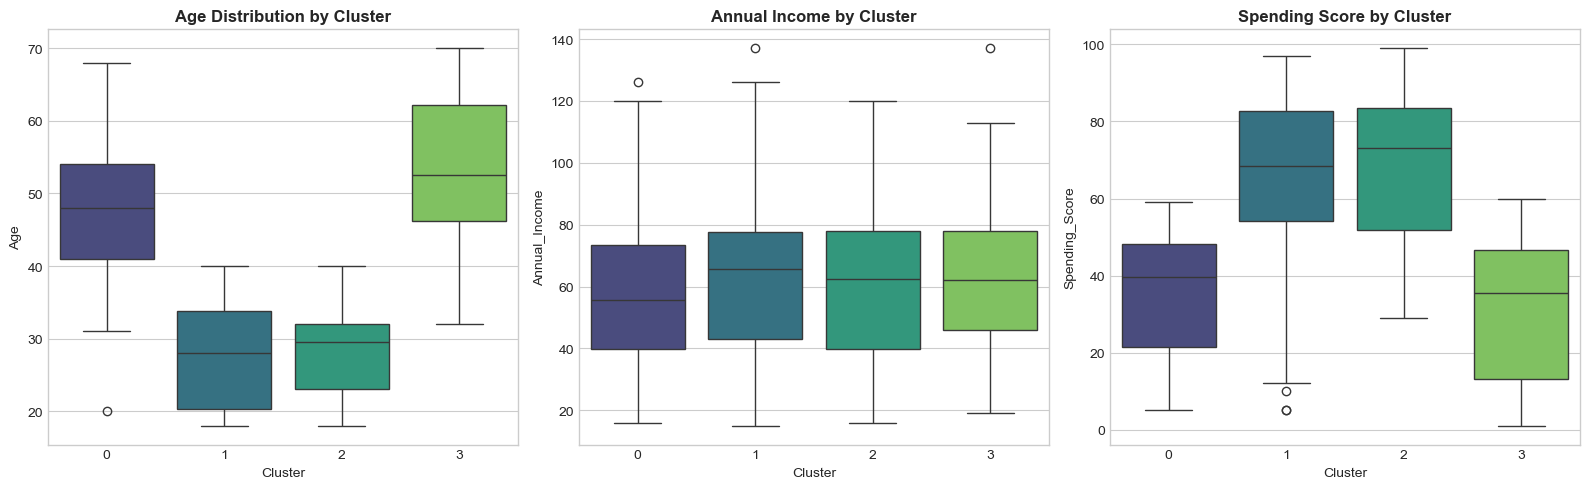

In [50]:
# 2. Boxplots for key features by Cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Cluster', y='Age', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Age Distribution by Cluster', fontweight='bold')

sns.boxplot(x='Cluster', y='Annual_Income', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Annual Income by Cluster', fontweight='bold')

sns.boxplot(x='Cluster', y='Spending_Score', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Spending Score by Cluster', fontweight='bold')

plt.tight_layout()
plt.show()

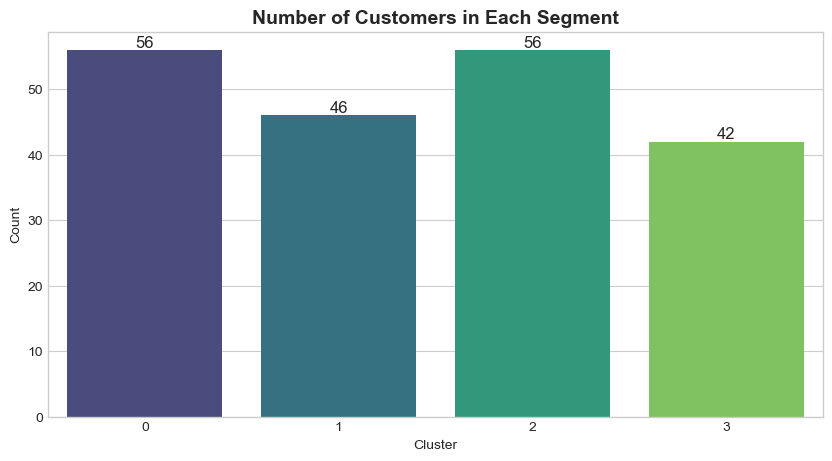

In [52]:
# 3. Count of customers per persona
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='Cluster', data=df, palette='viridis')
plt.title('Number of Customers in Each Segment', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Count')

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.show()

## 7. Conclusion & Business Impact

We successfully built a complete unsupervised learning pipeline that transformed raw, unlabeled customer data into four clear and actionable market segments:

| Cluster | Persona                          | Key Characteristics                          | Recommended Strategy                     |
|---------|----------------------------------|----------------------------------------------|------------------------------------------|
| 0       | The Affluent Conservatives       | High Income + Low Spending + Older           | High-touch support, warranties, loyalty  |
| 1       | The High-Value Trendsetters      | High Income + High Spending + Young-Adult    | Exclusive perks, early access, VIP       |
| 2       | The Budget-Conscious Explorers   | Low Income + High Spending + Young           | Flash sales, influencer, BNPL            |
| 3       | The Conservative Minimizers      | Low Income + Low Spending + Older            | Value pricing, basic products            |

### Key Technical Achievements
- Applied proper **Standardization** to remove scale bias
- Used **PCA** for dimensionality reduction and visualization
- Selected optimal **K=4** using both Elbow Method and business logic
- Reverse-engineered centroids back to original human-readable scale
- Translated mathematical clusters into clear marketing personas

### Next Possible Improvements
- Add more behavioral features (RFM, product categories, frequency)
- Try Hierarchical Clustering or Gaussian Mixture Models for comparison
- Deploy the model for real-time customer assignment
- Build a simple Streamlit / Gradio dashboard for ttomer Segmentation project.

In [56]:
# Save the final dataset with cluster labels
df.to_csv("Mall_Customers_Segmented.csv", index=False)
print("Final segmented dataset saved as 'Mall_Customers_Segmented.csv'")

# Optional: Save the persona summary
profile.to_csv("Customer_Personas_Summary.csv")
print("Persona summary saved as 'Customer_Personas_Summary.csv'")

Final segmented dataset saved as 'Mall_Customers_Segmented.csv'
Persona summary saved as 'Customer_Personas_Summary.csv'
